<a href="https://colab.research.google.com/github/ellal8353/Plan-A/blob/main/Sephora_Skincare_Analysis_July_23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sephora Skincare Pricing & Consumer Preference Analysis

## Commercial Analytics Portfolio Project

**Author:** Your Name

**Objective**

This project analyzes relationships between product pricing, customer satisfaction, and consumer popularity across Sephora's skincare assortment. Using Python for data cleaning and statistical analysis, the project identifies pricing patterns and merchandising opportunities to support commercial decision-making.

---

### Research Questions

1. Do higher-priced skincare products receive higher customer ratings?

2. Does premium pricing lead to greater consumer interest?

3. Which factors best predict product popularity?

4. Which skincare categories support premium pricing?

5. Which products represent merchandising opportunities for Sephora?

# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

# 2. Load Data

In this section, we load the cleaned Sephora skincare dataset into Python. The dataset has already been filtered to skincare products and cleaned in Excel before being imported into Colab for analysis.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

folder_path = "/content/drive/MyDrive"

for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/drive/MyDrive/Sephora Project/product_info 4.csv
/content/drive/MyDrive/Sephora Project/Clean Data Sephora - for python.csv


In [ ]:
# Load the cleaned Sephora dataset
df = pd.read_csv("/content/drive/MyDrive/Sephora Project/Clean Data Sephora - for python.csv")

# 3. Data Inspection

In [ ]:
# Display the first five rows of the dataset
df.head()

,Brand Name,Loves Count (bin),Price Usd (bin),Primary Category,Product Name,Rating (bin),Secondary Category,Tertiary Category,Log Loves,Loves Count,Price Usd,Rating,Reviews
0,La Mer,6K,420,Skincare,The Concentrate Serum,4.500,Treatments,Face Serums,3.875929,7514,425.0,4.5187,563.0
1,La Mer,4K,410,Skincare,The Regenerating Serum,4.350,Treatments,Face Serums,3.728922,5356,410.0,4.3750,152.0
2,SK-II,2K,400,Skincare,Ultimate Revival Cream,4.425,Moisturizers,Moisturizers,3.481729,3031,400.0,4.4667,60.0
3,Dr. Barbara Sturm,0K,390,Skincare,Super Anti-Aging Night Cream,NaN,Moisturizers,Moisturizers,2.340444,218,395.0,NaN,NaN
4,Augustinus Bader,2K,390,Skincare,The Serum with TFC8,3.975,Treatments,Face Serums,3.407731,2556,390.0,3.9877,81.0


In [ ]:
# Display the number of rows and columns
df.shape

(1739, 13)

In [ ]:
# Display all column names
df.columns

Index(['Brand Name', 'Loves Count (bin)', 'Price Usd (bin)',
       'Primary Category', 'Product Name', 'Rating (bin)',
       'Secondary Category', 'Tertiary Category', 'Log Loves', 'Loves Count',
       'Price Usd', 'Rating', 'Reviews'],
      dtype='object')

In [ ]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1739 entries, 0 to 1738
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Brand Name          1739 non-null   object 
 1   Loves Count (bin)   1739 non-null   object 
 2   Price Usd (bin)     1739 non-null   int64  
 3   Primary Category    1739 non-null   object 
 4   Product Name        1739 non-null   object 
 5   Rating (bin)        1705 non-null   float64
 6   Secondary Category  1739 non-null   object 
 7   Tertiary Category   1739 non-null   object 
 8   Log Loves           1739 non-null   float64
 9   Loves Count         1739 non-null   int64  
 10  Price Usd           1739 non-null   float64
 11  Rating              1705 non-null   float64
 12  Reviews             1705 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 176.7+ KB


# 4. Data Cleaning

### Missing Values

Before cleaning the dataset, we evaluate the extent of missing data. This helps determine whether observations can reasonably be removed without introducing meaningful bias into the analysis.

In [ ]:
# Count missing values in each column
df.isnull().sum()

,0
Brand Name,0
Loves Count (bin),0
Price Usd (bin),0
Primary Category,0
Product Name,0
Rating (bin),34
Secondary Category,0
Tertiary Category,0
Log Loves,0
Loves Count,0


### Interpretation

The dataset contains missing values only in the **Rating**, **Reviews**, and **Rating (bin)** columns. Specifically, 34 out of 1,739 products (approximately 2.0%) do not have customer ratings or review counts. Because this represents a small proportion of the dataset, removing these observations is unlikely to meaningfully affect the analysis.

### Remove Tableau-Specific Columns

The dataset includes several binned variables that were created for Tableau visualizations. These variables are not needed for statistical analysis in Python and are removed to simplify the dataset.

In [ ]:
# Remove Tableau-generated bin columns
df = df.drop(columns=[
    'Loves Count (bin)',
    'Price Usd (bin)',
    'Rating (bin)'
])

# Display the remaining columns
df.columns

Index(['Brand Name', 'Primary Category', 'Product Name', 'Secondary Category',
       'Tertiary Category', 'Log Loves', 'Loves Count', 'Price Usd', 'Rating',
       'Reviews'],
      dtype='object')

### Check for Duplicate Products

Before proceeding with analysis, we verify that each product appears only once in the dataset. Duplicate products could bias descriptive statistics and statistical models.

In [ ]:
# Check for duplicate brand-product combinations
duplicates = df.duplicated(subset=['Brand Name', 'Product Name'])

duplicates.sum()

np.int64(5)

### Inspect Duplicate Products

Five potential duplicate brand–product combinations were identified. Before removing any observations, we inspect these records to determine whether they are true duplicates or represent distinct products that share the same name.

In [ ]:
# Display all potential duplicate products
df[df.duplicated(subset=['Brand Name', 'Product Name'], keep=False)] \
    .sort_values(['Brand Name', 'Product Name'])

,Brand Name,Primary Category,Product Name,Secondary Category,Tertiary Category,Log Loves,Loves Count,Price Usd,Rating,Reviews
1166,CLINIQUE,Skincare,Clarifying Lotion 2,Cleansers,Toners,2.737193,545,36.0,4.4286,7.0
1515,CLINIQUE,Skincare,Clarifying Lotion 2,Cleansers,Toners,4.589682,38875,20.0,4.3815,1376.0
1167,CLINIQUE,Skincare,Clarifying Lotion 3,Cleansers,Toners,2.761928,577,36.0,4.1667,6.0
1517,CLINIQUE,Skincare,Clarifying Lotion 3,Cleansers,Toners,4.386089,24326,20.0,4.3181,918.0
1657,SEPHORA COLLECTION,Skincare,Melting Cleansing Balm Cleanse + Balance,Cleansers,Face Wash & Cleansers,4.322591,21017,12.0,3.6314,331.0
1659,SEPHORA COLLECTION,Skincare,Melting Cleansing Balm Cleanse + Balance,Cleansers,Face Wash & Cleansers,4.201506,15903,12.0,4.0131,153.0
586,Sunday Riley,Skincare,C.E.O. Afterglow Brightening Vitamin C Moistur...,Moisturizers,Moisturizers,4.219506,16576,65.0,4.6660,527.0
1502,Sunday Riley,Skincare,C.E.O. Afterglow Brightening Vitamin C Moistur...,Moisturizers,Moisturizers,3.449941,2817,22.0,4.6660,527.0
1599,Youth To The People,Skincare,Mini Mandelic Acid + Superfood Unity Exfoliant,Cleansers,Toners,4.564666,36699,16.0,4.6747,584.0
1600,Youth To The People,Skincare,Mini Mandelic Acid + Superfood Unity Exfoliant,Cleansers,Toners,3.813648,6510,16.0,4.8000,5.0


### Interpretation

Five potential duplicate brand–product combinations were identified. Inspection showed that these observations often differed in price, review count, or popularity, suggesting they likely represent different product sizes, formulations, or separate product listings rather than erroneous duplicates. Therefore, no observations were removed.

# 5. Exploratory Data Analysis

## 5.1 Price Distribution

We begin by examining the distribution of product prices across Sephora's skincare assortment. Understanding how prices are distributed provides context for later analyses exploring relationships between price, customer ratings, and consumer popularity.

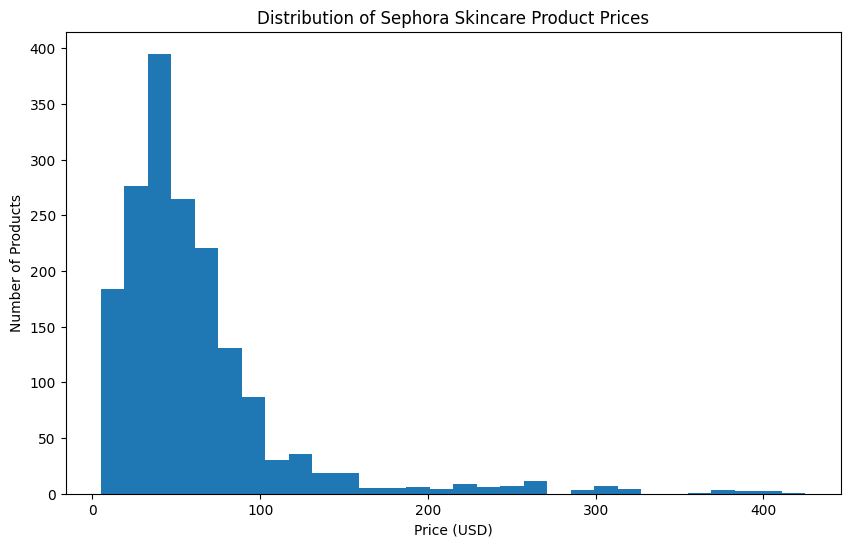

In [ ]:
# Create a histogram of product prices

plt.figure(figsize=(10,6))

plt.hist(df['Price Usd'], bins=30)

plt.title('Distribution of Sephora Skincare Product Prices')

plt.xlabel('Price (USD)')

plt.ylabel('Number of Products')

plt.show()

### Interpretation

**Objective observations**

- Product prices range from **$5 to $425**.
- The distribution is strongly right-skewed.
- The median product price is **$48**, while the mean is **$61**, indicating that a relatively small number of high-priced products increase the average price.
- Seventy-five percent of products are priced at **$72 or below**, suggesting that most of Sephora's skincare assortment is concentrated in the lower-to-mid prestige price range.

**Business interpretation**

Sephora's skincare assortment is concentrated within the prestige beauty price tier rather than the mass-market or ultra-luxury segments. Although premium-priced products are available, they represent a relatively small proportion of the overall assortment and have a limited influence on the overall pricing mix.

In [ ]:
# Summary statistics for product prices
df['Price Usd'].describe()

,Price Usd
count,1739.000000
mean,61.000897
std,53.020684
min,5.000000
25%,32.000000
50%,48.000000
75%,72.000000
max,425.000000


## 5.2 Rating Distribution

Before examining the relationship between price and customer satisfaction, we first explore the distribution of product ratings. This helps determine whether customer ratings vary meaningfully across Sephora's skincare assortment or are concentrated within a narrow range.

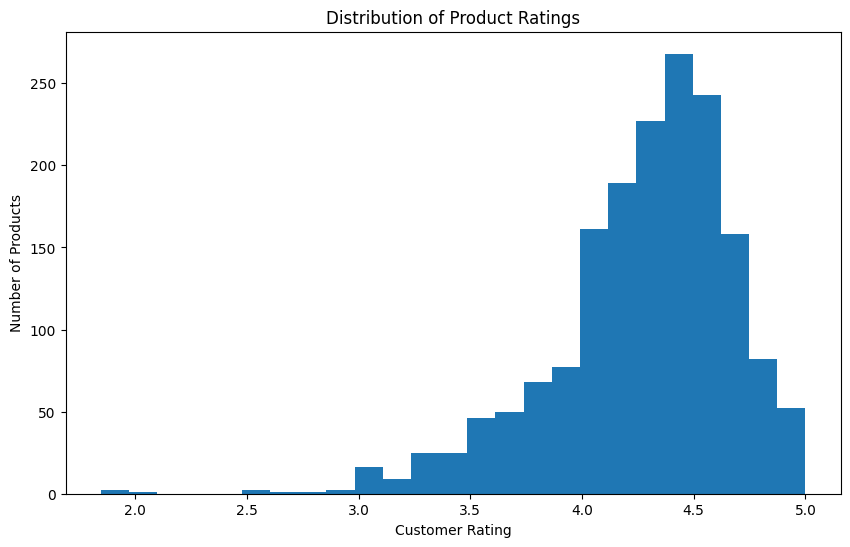

In [ ]:
# Histogram of customer ratings

plt.figure(figsize=(10,6))

plt.hist(df['Rating'].dropna(), bins=25)

plt.title('Distribution of Product Ratings')

plt.xlabel('Customer Rating')

plt.ylabel('Number of Products')

plt.show()

### Interpretation

**Objective observations**

- Customer ratings range from approximately **1.8 to 5.0**.
- Most products are rated between **4.0 and 4.7 stars**.
- The distribution is left-skewed, with relatively few products receiving ratings below **3.5**.
- Very low-rated products are rare.

**Business interpretation**

Customer satisfaction is generally high across Sephora's skincare assortment. Because ratings are concentrated within a relatively narrow range, customer ratings alone may provide limited ability to distinguish between products. This suggests that other factors—such as brand reputation, pricing, marketing, and visibility—may play a larger role in explaining product popularity.

In [ ]:
df['Rating'].describe()

,Rating
count,1705.000000
mean,4.269082
std,0.410085
min,1.846200
25%,4.068700
50%,4.341500
75%,4.545500
max,5.000000


### Interpretation

**Objective observations**

- Customer ratings range from **1.85 to 5.00** stars.
- The average product rating is **4.27**, while the median is **4.34**.
- Ratings are tightly concentrated, with a standard deviation of only **0.41**.
- Most products receive ratings between approximately **4.0 and 4.6** stars, while ratings below **3.5** are relatively uncommon.

**Business interpretation**

Customer satisfaction is consistently high across Sephora's skincare assortment. Because ratings are concentrated within a relatively narrow range, customer ratings alone may provide limited ability to differentiate products. This suggests that other factors—such as brand reputation, pricing, marketing exposure, and review volume—may play a larger role in explaining product popularity.

## 5.3 Distribution of Product Popularity (Loves Count)

Before examining what drives product popularity, we first explore the distribution of Sephora's Loves Count. Understanding the shape of this distribution helps determine whether the raw popularity measure is suitable for statistical analysis or requires transformation.

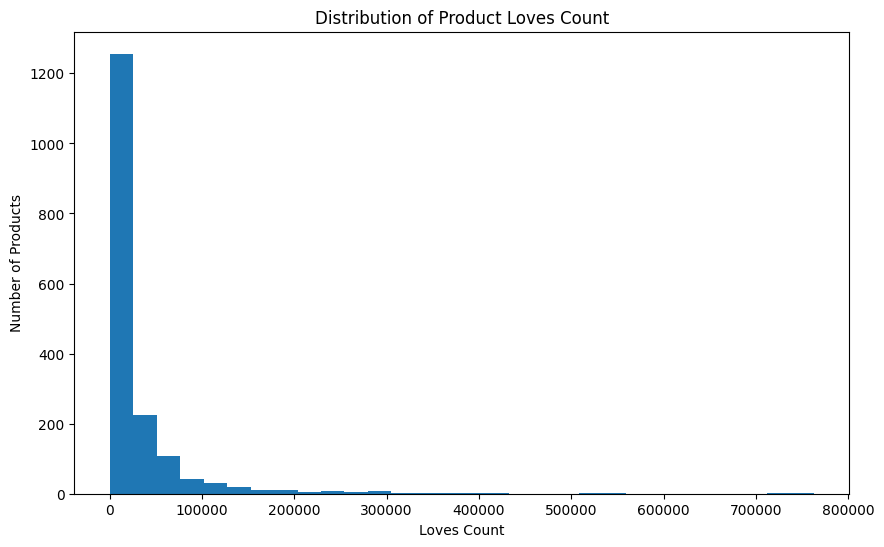

In [ ]:
# Histogram of Loves Count

plt.figure(figsize=(10,6))

plt.hist(df['Loves Count'], bins=30)

plt.title('Distribution of Product Loves Count')

plt.xlabel('Loves Count')

plt.ylabel('Number of Products')

plt.show()

In [ ]:
# Summary statistics for Loves Count

df['Loves Count'].describe()

,Loves Count
count,1739.000000
mean,29283.211041
std,56526.611302
min,0.000000
25%,4298.500000
50%,10594.000000
75%,29208.000000
max,763168.000000


### Interpretation

**Objective observations**

- Loves Count ranges from **0** to **763,168**.
- The distribution is extremely right-skewed.
- The median Loves Count is **10,594**, while the mean is **29,283**, indicating that a small number of highly popular products substantially increase the average.
- Product popularity varies widely across the assortment.

**Business interpretation**

Product popularity is highly concentrated. While most skincare products receive relatively modest numbers of Loves, a small number of blockbuster products accumulate exceptionally large followings. This extreme skewness suggests that the raw Loves Count is not well suited for visualization or statistical modeling without transformation.

## 5.4 Log Transformation of Loves Count

The distribution of Loves Count is highly right-skewed, with a small number of extremely popular products dominating the scale. To reduce this skewness and improve the interpretability of subsequent visualizations and statistical analyses, a logarithmic transformation is applied.

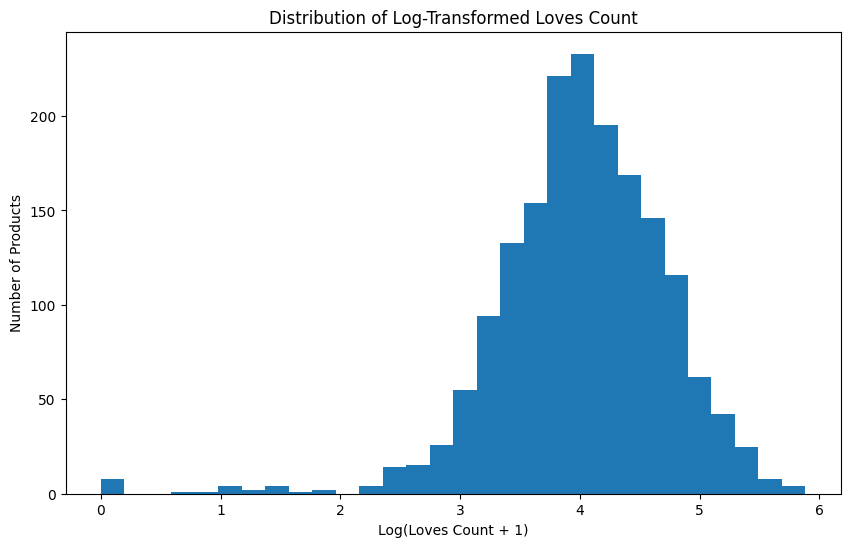

In [ ]:
# Histogram of Log Loves

plt.figure(figsize=(10,6))

plt.hist(df['Log Loves'], bins=30)

plt.title('Distribution of Log-Transformed Loves Count')

plt.xlabel('Log(Loves Count + 1)')

plt.ylabel('Number of Products')

plt.show()

## 5.4 Log Transformation of Loves Count

The distribution of Loves Count is extremely right-skewed, making it difficult to visualize relationships between popularity and other variables. A logarithmic transformation compresses the influence of extremely popular products while preserving the ordering of observations, creating a more balanced distribution for analysis.

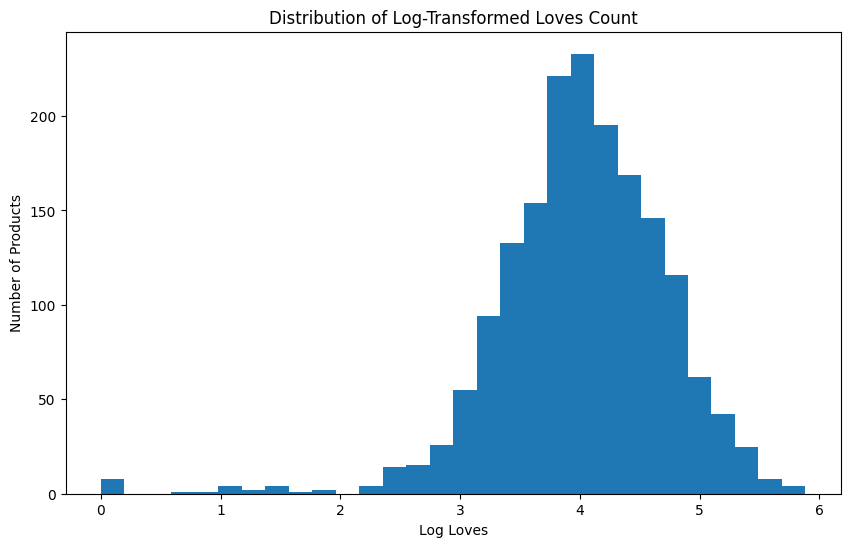

In [ ]:
# Histogram of log-transformed Loves Count

plt.figure(figsize=(10,6))

plt.hist(df['Log Loves'], bins=30)

plt.title('Distribution of Log-Transformed Loves Count')

plt.xlabel('Log Loves')

plt.ylabel('Number of Products')

plt.show()

In [ ]:
df['Log Loves'].describe()

,Log Loves
count,1739.000000
mean,4.010761
std,0.716957
min,0.000000
25%,3.633418
50%,4.025101
75%,4.465517
max,5.882621


### Interpretation

The original Loves Count variable was extremely right-skewed, with a small number of products receiving exceptionally large numbers of Loves. Applying a logarithmic transformation substantially reduced this skewness, producing a more balanced distribution while preserving the relative ordering of products.

Because the transformed variable is less influenced by extreme values, Log Loves will be used in subsequent visualizations and regression models to better evaluate the relationship between product popularity, price, and customer ratings.

## 5.5 Price vs Product Popularity

This visualization examines the relationship between product price and consumer popularity, measured using the log-transformed Loves Count. Using the transformed popularity metric reduces the influence of extremely popular products and makes overall trends easier to identify.

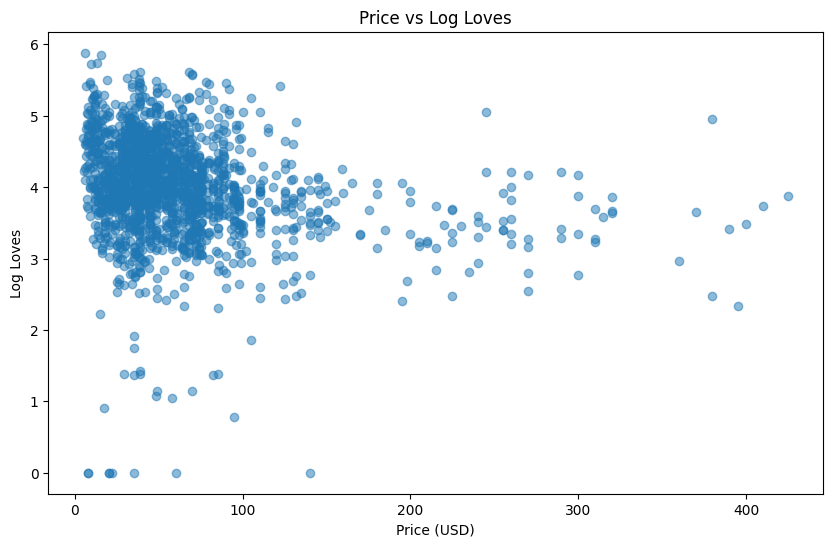

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Price Usd"],
    df["Log Loves"],
    alpha=0.5
)

plt.title("Price vs Log Loves")

plt.xlabel("Price (USD)")

plt.ylabel("Log Loves")

plt.show()

### Interpretation

The scatterplot suggests little evidence of a strong relationship between product price and consumer popularity. Products across a wide range of prices receive similar levels of popularity, and several lower-priced products are among the most popular in the dataset.

Although premium-priced products are present, they do not consistently receive higher Loves Counts than lower-priced alternatives. This suggests that higher prices alone are not associated with greater consumer interest.

The strength and statistical significance of this relationship will be evaluated more formally using regression analysis later in the project.

## 5.6 Price vs Customer Rating

This visualization examines whether higher-priced skincare products tend to receive higher customer ratings. If premium pricing reflects superior perceived quality, we may expect a positive relationship between price and ratings.

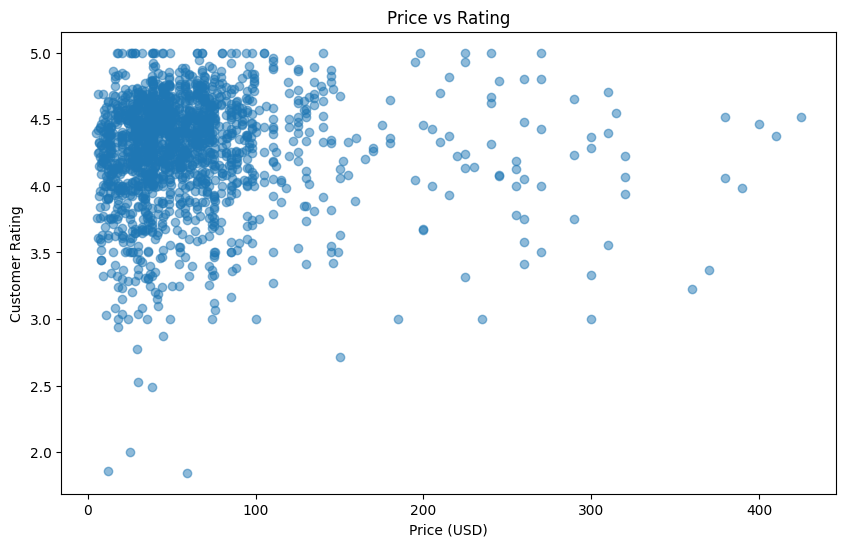

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Price Usd"],
    df["Rating"],
    alpha=0.5
)

plt.title("Price vs Rating")

plt.xlabel("Price (USD)")

plt.ylabel("Customer Rating")

plt.show()

### Interpretation

The scatterplot shows little evidence of a strong relationship between product price and customer ratings. Products across nearly every price point receive similar customer ratings, with most products concentrated between approximately 4.0 and 4.7 stars.

Although many premium-priced products receive high ratings, similarly high ratings are also common among lower-priced products. This suggests that higher prices do not consistently translate into greater customer satisfaction.

Regression analysis later in the project will quantify whether this apparent relationship is statistically meaningful.

## 5.7 Customer Ratings vs Product Popularity

This visualization examines whether products with higher customer ratings also tend to receive greater consumer popularity, measured using the log-transformed Loves Count.

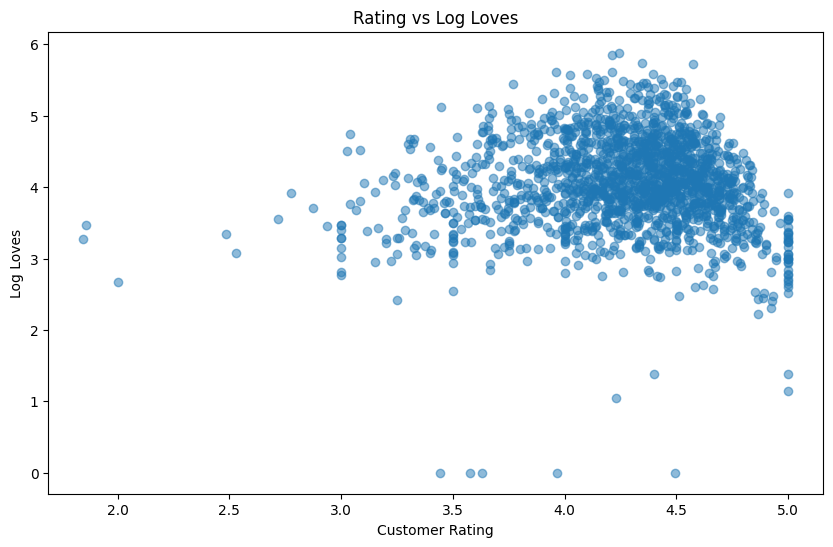

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Rating"],
    df["Log Loves"],
    alpha=0.5
)

plt.title("Rating vs Log Loves")

plt.xlabel("Customer Rating")

plt.ylabel("Log Loves")

plt.show()

### Interpretation

The relationship between customer ratings and product popularity appears positive but relatively weak. Products with higher ratings tend to receive greater popularity, although there is considerable variation across the rating range.

Highly rated products are not always the most popular, indicating that factors beyond customer satisfaction—such as brand recognition, marketing, and product visibility—likely contribute to consumer popularity.

The strength of this relationship will be evaluated quantitatively using correlation analysis and regression modeling.

# 6. Correlation Analysis

Before fitting regression models, we examine the pairwise correlations between the numerical variables. Correlation coefficients summarize the strength and direction of linear relationships and provide an initial indication of which variables may be useful predictors of product popularity.

In [ ]:
# Select numerical variables

numeric_df = df[['Price Usd', 'Rating', 'Log Loves']]

In [ ]:
numeric_df.corr()

,Price Usd,Rating,Log Loves
Price Usd,1.000000,0.019516,-0.222191
Rating,0.019516,1.000000,-0.005457
Log Loves,-0.222191,-0.005457,1.000000


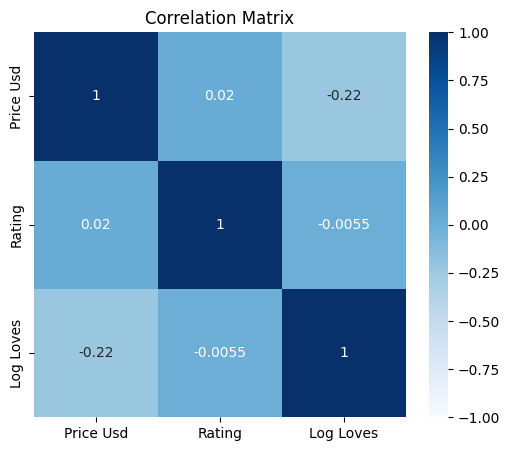

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")

plt.show()

### Interpretation

The correlation matrix indicates that none of the three variables exhibit strong linear relationships.

Price and customer ratings are essentially uncorrelated (r = 0.02), suggesting that more expensive skincare products do not consistently receive higher ratings.

Price and product popularity exhibit a weak negative correlation (r = -0.22), indicating that higher-priced products tend to receive slightly lower popularity on average.

Customer ratings and product popularity are effectively uncorrelated (r ≈ 0.00), suggesting that customer satisfaction alone does not explain differences in product popularity.

These results provide an initial indication of the relationships in the dataset and motivate the use of regression analysis to evaluate these effects more formally.

# 7. Linear Regression

Regression analysis estimates the relationship between product popularity and potential explanatory variables. Unlike correlation analysis, regression quantifies the expected change in the outcome variable while allowing us to evaluate statistical significance and overall model performance.

The first model examines whether product price predicts consumer popularity.

In [ ]:
import statsmodels.api as sm

In [ ]:
# Independent variable

X = df[['Price Usd']]

# Add intercept

X = sm.add_constant(X)

# Dependent variable

y = df['Log Loves']

In [ ]:
model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Log Loves   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     90.21
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           6.82e-21
Time:                        19:18:55   Log-Likelihood:                -1844.4
No. Observations:                1739   AIC:                             3693.
Df Residuals:                    1737   BIC:                             3704.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1940      0.026    164.059      0.000       4.144       4.244
Price Usd     -0.0030      0.000     -9.498      0.000      -0.004      -0.002
==============================================================================
Omnibus:                      537.350   Durbin-Watson:                   1.658
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3101.322
Skew:                          -1.324   Prob(JB):                         0.00
Kurtosis:                       8.983   Cond. No.                         123.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpretation

A simple linear regression was used to estimate the relationship between product price and consumer popularity (Log Loves).

The model found a statistically significant negative association between price and popularity (β = -0.0030, p < 0.001).

Holding all else constant, each additional dollar in price is associated with a small decrease in expected popularity.

However, the model explains only a small proportion of the overall variation in popularity (R² = 0.049), suggesting that many additional factors—such as brand strength, marketing, and product category—likely contribute to consumer engagement.

Overall, price alone is not a strong predictor of product popularity, although the observed relationship is statistically significant.

In [ ]:
# Create a temporary dataframe with only complete observations
reg_df = df[['Price Usd', 'Rating', 'Log Loves']].dropna()

X = reg_df[['Price Usd', 'Rating']]
X = sm.add_constant(X)

y = reg_df['Log Loves']

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Log Loves   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     50.37
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           5.61e-22
Time:                        19:18:55   Log-Likelihood:                -1646.5
No. Observations:                1705   AIC:                             3299.
Df Residuals:                    1702   BIC:                             3315.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2339      0.162     26.164      0.000       3.916       4.551
Price Usd     -0.0029      0.000    -10.034      0.000      -0.004      -0.002
Rating        -0.0013      0.038     -0.036      0.971      -0.075       0.072
==============================================================================
Omnibus:                      390.090   Durbin-Watson:                   1.574
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2298.179
Skew:                          -0.936   Prob(JB):                         0.00
Kurtosis:                       8.371   Cond. No.                         866.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Multiple Linear Regression

A multiple linear regression model was estimated using both product price and customer rating to predict product popularity (Log Loves).

Price remained a statistically significant predictor of popularity (p < 0.001), even after controlling for customer ratings.

In contrast, customer rating was not statistically significant (p = 0.971), suggesting that highly rated products are not necessarily the most popular once price is considered.

The model explained approximately 5.6% of the variation in product popularity (R² = 0.056). While statistically significant overall, the results indicate that additional factors—such as brand equity, marketing exposure, influencer activity, and product placement—likely account for much of the remaining variation in consumer engagement.

In [ ]:
df['Secondary Category'].value_counts()

,count
Secondary Category,
Moisturizers,543
Treatments,462
Cleansers,338
Eye Care,172
Masks,129
Sunscreen,95


In [ ]:
category_model = smf.ols(
    formula='Q("Log Loves") ~ Q("Price Usd") + C(Q("Secondary Category"), Treatment(reference="Moisturizers"))',
    data=df
).fit()

category_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Q("Log Loves")   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     16.83
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           5.79e-19
Time:                        19:18:55   Log-Likelihood:                -1839.1
No. Observations:                1739   AIC:                             3692.
Df Residuals:                    1732   BIC:                             3730.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=================================================================================================================================================
                                                                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         4.1787      0.038    108.724      0.000       4.103       4.254
C(Q("Secondary Category"), Treatment(reference="Moisturizers"))[T.Cleansers]     -0.0534      0.050     -1.070      0.285      -0.151       0.044
C(Q("Secondary Category"), Treatment(reference="Moisturizers"))[T.Eye Care]       0.0873      0.061      1.429      0.153      -0.033       0.207
C(Q("Secondary Category"), Treatment(reference="Moisturizers"))[T.Masks]          0.0945      0.069      1.374      0.170      -0.040       0.229
C(Q("Secondary Category"), Treatment(reference="Moisturizers"))[T.Sunscreen]     -0.0266      0.078     -0.340      0.734      -0.180       0.127
C(Q("Secondary Category"), Treatment(reference="Moisturizers"))[T.Treatments]     0.0772      0.044      1.745      0.081      -0.010       0.164
Q("Price Usd")                                                                   -0.0032      0.000     -9.602      0.000      -0.004      -0.003
==============================================================================
Omnibus:                      557.649   Durbin-Watson:                   1.662
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3398.111
Skew:                          -1.362   Prob(JB):                         0.00
Kurtosis:                       9.283   Cond. No.                         452.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Category Regression

A multiple linear regression was estimated to evaluate whether product category predicts popularity after controlling for price.

Moisturizers were selected as the reference category because they represent the largest product group in the dataset.

After controlling for price, none of the remaining skincare categories differed significantly from Moisturizers at the 5% significance level. Treatments showed a small positive trend toward higher popularity (β = 0.077, p = 0.081), although this relationship was not statistically significant.

Across all models, product price remained a significant negative predictor of popularity, suggesting that pricing is more strongly associated with consumer engagement than broad product category.

# 6. Statistical Analysis

# 7. Opportunity Analysis

# 8. Business Recommendations

# 9. Conclusion

#Ingredients Analysis

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "product_info 4.csv" in files:
        print(os.path.join(root, "product_info 4.csv"))

/content/drive/MyDrive/Sephora Project/product_info 4.csv


In [ ]:
raw = pd.read_csv("/content/drive/MyDrive/Sephora Project/product_info 4.csv")

In [ ]:
raw.columns

Index(['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count',
       'rating', 'reviews', 'size', 'variation_type', 'variation_value',
       'variation_desc', 'ingredients', 'price_usd', 'value_price_usd',
       'sale_price_usd', 'limited_edition', 'new', 'online_only',
       'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category',
       'secondary_category', 'tertiary_category', 'child_count',
       'child_max_price', 'child_min_price'],
      dtype='object')

## Ingredient Data Integration

Ingredient lists are sourced from the original Sephora dataset and merged into the cleaned skincare dataset. Brand, product name, price, and Loves Count are used as matching fields to distinguish between products with similar names or multiple sizes.

In [ ]:
raw[["product_name", "brand_name", "ingredients"]].head()

,product_name,brand_name,ingredients
0,Fragrance Discovery Set,19-69,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A..."
1,La Habana Eau de Parfum,19-69,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra..."
2,Rainbow Bar Eau de Parfum,19-69,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra..."
3,Kasbah Eau de Parfum,19-69,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra..."
4,Purple Haze Eau de Parfum,19-69,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra..."


In [ ]:
def parse_ingredients(text):
    if pd.isna(text):
        return []

    text = str(text).lower()

    text = (
        text.replace("[", "")
            .replace("]", "")
            .replace("'", "")
            .replace('"', "")
    )

    return [
        ingredient.strip()
        for ingredient in text.split(",")
        if ingredient.strip()
    ]


raw["ingredient_list"] = raw["ingredients"].apply(parse_ingredients)

In [ ]:
raw[["ingredients", "ingredient_list"]].head()

,ingredients,ingredient_list
0,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...","[capri eau de parfum:, alcohol denat. (sd alco..."
1,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...","[alcohol denat. (sd alcohol 39c), parfum (frag..."
2,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...","[alcohol denat. (sd alcohol 39c), parfum (frag..."
3,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...","[alcohol denat. (sd alcohol 39c), parfum (frag..."
4,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...","[alcohol denat. (sd alcohol 39c), parfum (frag..."


In [ ]:
ingredients_df = raw[
    [
        "brand_name",
        "product_name",
        "price_usd",
        "loves_count",
        "ingredient_list"
    ]
].copy()

ingredients_df = ingredients_df.rename(columns={
    "brand_name": "Brand Name",
    "product_name": "Product Name",
    "price_usd": "Price Usd",
    "loves_count": "Loves Count",
    "ingredient_list": "Ingredient List"
})

ingredients_df.head()

,Brand Name,Product Name,Price Usd,Loves Count,Ingredient List
0,19-69,Fragrance Discovery Set,35.0,6320,"[capri eau de parfum:, alcohol denat. (sd alco..."
1,19-69,La Habana Eau de Parfum,195.0,3827,"[alcohol denat. (sd alcohol 39c), parfum (frag..."
2,19-69,Rainbow Bar Eau de Parfum,195.0,3253,"[alcohol denat. (sd alcohol 39c), parfum (frag..."
3,19-69,Kasbah Eau de Parfum,195.0,3018,"[alcohol denat. (sd alcohol 39c), parfum (frag..."
4,19-69,Purple Haze Eau de Parfum,195.0,2691,"[alcohol denat. (sd alcohol 39c), parfum (frag..."


In [ ]:
rows_before_merge = len(df)

df = df.merge(
    ingredients_df,
    on=[
        "Brand Name",
        "Product Name",
        "Price Usd",
        "Loves Count"
    ],
    how="left"
)

print("Rows before merge:", rows_before_merge)
print("Rows after merge:", len(df))
print("Missing ingredient lists:", df["Ingredient List"].isna().sum())

Rows before merge: 1739
Rows after merge: 1739
Missing ingredient lists: 111


In [ ]:
from collections import Counter

ingredient_counter = Counter()

for ingredient_list in df["Ingredient List"].dropna():
    ingredient_counter.update(set(ingredient_list))

ingredient_counts = (
    pd.DataFrame(
        ingredient_counter.items(),
        columns=["Ingredient", "Product Count"]
    )
    .sort_values("Product Count", ascending=False)
    .reset_index(drop=True)
)

ingredient_counts.head(30)

,Ingredient,Product Count
0,glycerin,1263
1,phenoxyethanol,764
2,butylene glycol,758
3,citric acid,611
4,tocopherol,608
5,sodium hyaluronate,605
6,propanediol,588
7,xanthan gum,568
8,ethylhexylglycerin,558
9,caprylyl glycol,534


In [ ]:
common_ingredients = ingredient_counts.loc[
    ingredient_counts["Product Count"] >= 30,
    "Ingredient"
].tolist()

len(common_ingredients)

328

In [ ]:
import re

for ingredient in common_ingredients:
    df[f"ing_{ingredient}"] = (
        df["Ingredient List"]
        .apply(
            lambda x: int(
                isinstance(x, list) and ingredient in x
            )
        )
    )

/tmp/ipykernel_5668/1240272682.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"ing_{ingredient}"] = (
/tmp/ipykernel_5668/1240272682.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"ing_{ingredient}"] = (
/tmp/ipykernel_5668/1240272682.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()

In [ ]:
analysis = df.dropna(subset=["Rating", "Price Usd"]).copy()

In [ ]:
ingredient_cols = [
    c for c in analysis.columns
    if c.startswith("ing_")
]

formula = (
    "Rating ~ Q('Price Usd') + "
    "C(Q('Secondary Category')) + "
    + " + ".join([f"Q('{c}')" for c in ingredient_cols])
)

print(formula[:500])

Rating ~ Q('Price Usd') + C(Q('Secondary Category')) + Q('ing_glycerin') + Q('ing_phenoxyethanol') + Q('ing_butylene glycol') + Q('ing_citric acid') + Q('ing_tocopherol') + Q('ing_sodium hyaluronate') + Q('ing_propanediol') + Q('ing_xanthan gum') + Q('ing_ethylhexylglycerin') + Q('ing_caprylyl glycol') + Q('ing_caprylic/capric triglyceride') + Q('ing_sodium hydroxide') + Q('ing_sodium benzoate') + Q('ing_potassium sorbate') + Q('ing_tocopheryl acetate') + Q('ing_disodium edta') + Q('ing_water') 


In [ ]:
import statsmodels.api as sm
import pandas as pd

# Ingredient columns created from the actual dataset
ingredient_cols = [
    c for c in analysis.columns
    if c.startswith("ing_")
]

# Convert product category into numeric dummy columns
category_dummies = pd.get_dummies(
    analysis["Secondary Category"],
    prefix="category",
    drop_first=True,
    dtype=int
)

# Build the predictor table
X = pd.concat(
    [
        analysis[["Price Usd"]].reset_index(drop=True),
        category_dummies.reset_index(drop=True),
        analysis[ingredient_cols].reset_index(drop=True)
    ],
    axis=1
)

# Ensure every predictor is numeric
X = X.astype(float)

# Add the intercept
X = sm.add_constant(X)

# Outcome variable
y = analysis["Rating"].reset_index(drop=True).astype(float)

# Fit the regression
ingredient_model = sm.OLS(y, X).fit()

ingredient_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Rating   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     1.601
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           5.15e-09
Time:                        19:37:14   Log-Likelihood:                -617.99
No. Observations:                1705   AIC:                             1906.
Df Residuals:                    1370   BIC:                             3729.
Df Model:                         334                                         
Covariance Type:            nonrobust                                         
=======================================================================================================================================
                                                                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------
const                                                                   4.3304      0.037    116.555      0.000       4.258       4.403
Price Usd                                                               0.0003      0.000      1.247      0.213      -0.000       0.001
category_Eye Care                                                      -0.2059      0.052     -3.939      0.000      -0.308      -0.103
category_Masks                                                         -0.0546      0.051     -1.067      0.286      -0.155       0.046
category_Moisturizers                                                  -0.0766      0.038     -2.042      0.041      -0.150      -0.003
category_Sunscreen                                                     -0.1725      0.067     -2.574      0.010      -0.304      -0.041
category_Treatments                                                    -0.0698      0.038     -1.833      0.067      -0.145       0.005
ing_glycerin                                                            0.0364      0.033      1.108      0.268      -0.028       0.101
ing_phenoxyethanol                                                     -0.0813      0.030     -2.699      0.007      -0.140      -0.022
ing_butylene glycol                                                     0.0270      0.028      0.968      0.333      -0.028       0.082
ing_citric acid                                                        -0.0073      0.029     -0.251      0.802      -0.064       0.049
ing_tocopherol                                                          0.0384      0.029      1.311      0.190      -0.019       0.096
ing_sodium hyaluronate                                                 -0.0490      0.027     -1.801      0.072      -0.102       0.004
ing_propanediol                                                        -0.0143      0.028     -0.509      0.611      -0.069       0.041
ing_xanthan gum                                                        -0.0135      0.027     -0.493      0.622      -0.067       0.040
ing_ethylhexylglycerin                                                 -0.0131      0.030     -0.434      0.664      -0.072       0.046
ing_caprylyl glycol                                                    -0.0448      0.031     -1.451      0.147      -0.105       0.016
ing_caprylic/capric triglyceride                                       -0.0191      0.029     -0.664      0.507      -0.076       0.037
ing_sodium hydroxide                                                    0.0280      0.031      0.905      0.366      -0.033       0.089
ing_sodium benzoate                                                    -0.0381      0.035  

In [ ]:
results = pd.DataFrame({
    "Ingredient": ingredient_cols,
    "Coefficient": ingredient_model.params[ingredient_cols].values,
    "P-value": ingredient_model.pvalues[ingredient_cols].values
})

results = results.sort_values(
    "Coefficient",
    ascending=False
)

results.head(20)

,Ingredient,Coefficient,P-value
324,ing_yeast amino acids,0.438140,0.152125
263,ing_alanine,0.298208,0.409815
314,ing_solanum melongena (eggplant) fruit extract,0.293167,0.075712
310,ing_anhydroxylitol,0.261859,0.222575
298,ing_phytosterols,0.225869,0.009662
240,ing_inulin,0.220075,0.020255
243,ing_arachidyl glucoside,0.217695,0.451729
130,ing_palmitoyl tetrapeptide-7,0.212531,0.024904
277,ing_capryloyl glycerin/sebacic acid copolymer,0.170214,0.583594
186,ing_ocimum sanctum leaf extract,0.154410,0.177156


In [ ]:
from statsmodels.stats.multitest import multipletests

results["Adj P-value"] = multipletests(
    results["P-value"],
    method="fdr_bh"
)[1]

results = results.sort_values(
    "Adj P-value"
)

results.head(30)

,Ingredient,Coefficient,P-value,Adj P-value
298,ing_phytosterols,0.225869,0.009662,0.474791
119,ing_decyl glucoside,-0.159819,0.010133,0.474791
1,ing_phenoxyethanol,-0.081299,0.007039,0.474791
16,ing_water,-0.098949,0.007997,0.474791
100,ing_parfum (fragrance),-0.179405,0.006904,0.474791
144,ing_polysorbate 80,-0.221295,0.003788,0.474791
95,ing_sucrose,-0.162767,0.008605,0.474791
109,ing_curcuma longa (turmeric) root extract,-0.206209,0.012991,0.527653
252,ing_sodium acrylates copolymer,-0.200505,0.014478,0.527653
130,ing_palmitoyl tetrapeptide-7,0.212531,0.024904,0.589177


## Ingredient Pricing and Customer Satisfaction

This analysis examines whether lower-priced products receive higher customer ratings than premium-priced alternatives containing the same ingredient. Products with fewer than 20 reviews are excluded from product-level comparisons to reduce the influence of unstable ratings. Product category is controlled for when estimating the relationship between price and rating.

In [ ]:
# Keep products with usable ingredient, price, rating, and review data

ingredient_analysis = df[
    df["Ingredient List"].apply(lambda x: isinstance(x, list) and len(x) > 0)
].copy()

ingredient_analysis = ingredient_analysis.dropna(
    subset=["Price Usd", "Rating", "Reviews", "Secondary Category"]
)

# Require enough reviews for a reasonably stable rating
ingredient_analysis = ingredient_analysis[
    ingredient_analysis["Reviews"] >= 20
].copy()

print("Products included:", len(ingredient_analysis))

Products included: 1367


In [ ]:
ingredient_rows = []

for ingredient in common_ingredients:
    subset = ingredient_analysis[
        ingredient_analysis["Ingredient List"].apply(
            lambda x: ingredient in x
        )
    ]

    if len(subset) >= 20:
        ingredient_rows.append({
            "Ingredient": ingredient,
            "Products": len(subset),
            "Average Price": subset["Price Usd"].mean(),
            "Median Price": subset["Price Usd"].median(),
            "Minimum Price": subset["Price Usd"].min(),
            "Maximum Price": subset["Price Usd"].max(),
            "Average Rating": subset["Rating"].mean(),
            "Median Reviews": subset["Reviews"].median()
        })

ingredient_price_summary = pd.DataFrame(ingredient_rows)

ingredient_price_summary = ingredient_price_summary.sort_values(
    "Products",
    ascending=False
).reset_index(drop=True)

ingredient_price_summary.head(30)

,Ingredient,Products,Average Price,Median Price,Minimum Price,Maximum Price,Average Rating,Median Reviews
0,glycerin,1066,58.457852,48.00,5.50,425.0,4.296184,270.0
1,phenoxyethanol,662,60.018716,49.75,5.50,425.0,4.238081,291.5
2,butylene glycol,635,63.522094,49.00,5.50,410.0,4.280028,291.0
3,tocopherol,522,60.941571,52.00,5.99,425.0,4.325436,315.5
4,citric acid,503,55.668270,48.00,5.50,290.0,4.298683,271.0
5,sodium hyaluronate,501,64.176866,54.00,6.50,380.0,4.256418,273.0
6,propanediol,500,56.083620,46.00,6.50,370.0,4.331506,274.5
7,ethylhexylglycerin,472,59.224492,49.00,5.50,370.0,4.277029,302.5
8,xanthan gum,470,60.147830,48.50,5.99,320.0,4.312996,259.5
9,caprylyl glycol,447,57.201611,48.00,7.00,260.0,4.281505,292.0


In [ ]:
import statsmodels.formula.api as smf

ingredient_relationships = []

for ingredient in common_ingredients:

    subset = ingredient_analysis[
        ingredient_analysis["Ingredient List"].apply(
            lambda x: ingredient in x
        )
    ].copy()

    # Require enough observations and price variation
    if len(subset) < 30 or subset["Price Usd"].nunique() < 5:
        continue

    model = smf.ols(
        formula='Rating ~ Q("Price Usd") + C(Q("Secondary Category"))',
        data=subset
    ).fit(cov_type="HC3")

    price_coef = model.params['Q("Price Usd")']
    price_pvalue = model.pvalues['Q("Price Usd")']

    ingredient_relationships.append({
        "Ingredient": ingredient,
        "Products": len(subset),
        "Average Price": subset["Price Usd"].mean(),
        "Average Rating": subset["Rating"].mean(),
        "Price Coefficient": price_coef,
        "Effect per $10": price_coef * 10,
        "P-value": price_pvalue,
        "R-squared": model.rsquared
    })

ingredient_price_models = pd.DataFrame(ingredient_relationships)

ingredient_price_models.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2


,Ingredient,Products,Average Price,Average Rating,Price Coefficient,Effect per $10,P-value,R-squared
0,glycerin,1066,58.457852,4.296184,0.000693,0.006927,0.001820,0.060059
1,phenoxyethanol,662,60.018716,4.238081,0.000448,0.004475,0.237835,0.082841
2,butylene glycol,635,63.522094,4.280028,0.000021,0.000205,0.945349,0.065215
3,citric acid,503,55.668270,4.298683,0.000586,0.005863,0.217110,0.065401
4,tocopherol,522,60.941571,4.325436,0.000520,0.005204,0.169218,0.085399


In [ ]:
from statsmodels.stats.multitest import multipletests

ingredient_price_models["Adjusted P-value"] = multipletests(
    ingredient_price_models["P-value"],
    method="fdr_bh"
)[1]

ingredient_price_models = ingredient_price_models.sort_values(
    "Adjusted P-value"
).reset_index(drop=True)

ingredient_price_models.head(30)

,Ingredient,Products,Average Price,Average Rating,Price Coefficient,Effect per $10,P-value,R-squared,Adjusted P-value
0,phytic acid,42,52.840000,4.346626,0.007801,0.078008,0.000008,0.312620,0.002213
1,sodium chloride,168,50.580833,4.240307,0.001804,0.018041,0.000034,0.168001,0.004642
2,serine,43,48.604419,4.372781,0.003345,0.033449,0.000176,0.175276,0.012570
3,1,285,48.587123,4.380077,0.002092,0.020915,0.000183,0.084723,0.012570
4,2-hexanediol,269,48.551413,4.381815,0.002030,0.020302,0.000376,0.074819,0.020699
5,dehydroacetic acid,51,40.861373,4.267725,0.004668,0.046677,0.000571,0.338078,0.026182
6,polysorbate 20,181,58.869890,4.280117,0.001975,0.019746,0.001708,0.067390,0.062564
7,glycerin,1066,58.457852,4.296184,0.000693,0.006927,0.001820,0.060059,0.062564
8,polysilicone-11,74,84.525270,4.133572,0.001231,0.012309,0.003204,0.145059,0.088120
9,trisodium ethylenediamine disuccinate,104,41.171154,4.245172,0.002708,0.027078,0.003057,0.188595,0.088120


In [ ]:
significant_price_relationships = ingredient_price_models[
    ingredient_price_models["Adjusted P-value"] < 0.05
].copy()

significant_price_relationships

,Ingredient,Products,Average Price,Average Rating,Price Coefficient,Effect per $10,P-value,R-squared,Adjusted P-value
0,phytic acid,42,52.840000,4.346626,0.007801,0.078008,0.000008,0.312620,0.002213
1,sodium chloride,168,50.580833,4.240307,0.001804,0.018041,0.000034,0.168001,0.004642
2,serine,43,48.604419,4.372781,0.003345,0.033449,0.000176,0.175276,0.012570
3,1,285,48.587123,4.380077,0.002092,0.020915,0.000183,0.084723,0.012570
4,2-hexanediol,269,48.551413,4.381815,0.002030,0.020302,0.000376,0.074819,0.020699
5,dehydroacetic acid,51,40.861373,4.267725,0.004668,0.046677,0.000571,0.338078,0.026182


In [ ]:
quartile_comparisons = []

for ingredient in common_ingredients:

    subset = ingredient_analysis[
        ingredient_analysis["Ingredient List"].apply(
            lambda x: ingredient in x
        )
    ].copy()

    if len(subset) < 40 or subset["Price Usd"].nunique() < 4:
        continue

    # qcut divides products into four similarly sized price groups
    try:
        subset["Price Quartile"] = pd.qcut(
            subset["Price Usd"],
            q=4,
            labels=["Cheapest 25%", "Q2", "Q3", "Most Expensive 25%"],
            duplicates="drop"
        )
    except ValueError:
        continue

    cheapest = subset[
        subset["Price Quartile"] == "Cheapest 25%"
    ]

    expensive = subset[
        subset["Price Quartile"] == "Most Expensive 25%"
    ]

    if len(cheapest) == 0 or len(expensive) == 0:
        continue

    quartile_comparisons.append({
        "Ingredient": ingredient,
        "Products": len(subset),
        "Cheapest Avg Price": cheapest["Price Usd"].mean(),
        "Cheapest Avg Rating": cheapest["Rating"].mean(),
        "Expensive Avg Price": expensive["Price Usd"].mean(),
        "Expensive Avg Rating": expensive["Rating"].mean(),
        "Rating Difference": (
            cheapest["Rating"].mean()
            - expensive["Rating"].mean()
        )
    })

ingredient_quartiles = pd.DataFrame(quartile_comparisons)

ingredient_quartiles = ingredient_quartiles.sort_values(
    "Rating Difference",
    ascending=False
).reset_index(drop=True)

ingredient_quartiles.head(30)

,Ingredient,Products,Cheapest Avg Price,Cheapest Avg Rating,Expensive Avg Price,Expensive Avg Rating,Rating Difference
0,salix alba (willow) bark extract,42,26.272727,4.404364,107.636364,4.153627,0.250736
1,lavandula angustifolia (lavender) oil,60,29.800000,4.451233,109.600000,4.266507,0.184727
2,leuconostoc/radish root ferment filtrate,141,25.081389,4.335667,133.741935,4.162252,0.173415
3,sorbitol,70,28.421053,4.198911,194.111111,4.044594,0.154316
4,sodium lactate,74,19.504211,4.264216,108.187500,4.115631,0.148585
5,hexylene glycol,118,23.940312,4.271225,107.137931,4.136576,0.134649
6,hydroxyethylcellulose,67,15.667059,4.274700,93.133333,4.143153,0.131547
7,linalool.,78,28.125000,4.275875,105.200000,4.150170,0.125705
8,inositol,41,37.083333,4.275958,138.800000,4.151160,0.124798
9,benzoic acid,40,20.570000,4.296830,114.700000,4.175890,0.120940


In [ ]:
from scipy.stats import ttest_ind

quartile_tests = []

for ingredient in common_ingredients:

    subset = ingredient_analysis[
        ingredient_analysis["Ingredient List"].apply(
            lambda x: ingredient in x
        )
    ].copy()

    if len(subset) < 40 or subset["Price Usd"].nunique() < 4:
        continue

    try:
        subset["Price Quartile"] = pd.qcut(
            subset["Price Usd"],
            q=4,
            labels=["Cheapest 25%", "Q2", "Q3", "Most Expensive 25%"],
            duplicates="drop"
        )
    except ValueError:
        continue

    cheapest_ratings = subset.loc[
        subset["Price Quartile"] == "Cheapest 25%",
        "Rating"
    ]

    expensive_ratings = subset.loc[
        subset["Price Quartile"] == "Most Expensive 25%",
        "Rating"
    ]

    if len(cheapest_ratings) < 5 or len(expensive_ratings) < 5:
        continue

    test = ttest_ind(
        cheapest_ratings,
        expensive_ratings,
        equal_var=False,
        nan_policy="omit"
    )

    quartile_tests.append({
        "Ingredient": ingredient,
        "Products": len(subset),
        "Cheapest Avg Rating": cheapest_ratings.mean(),
        "Expensive Avg Rating": expensive_ratings.mean(),
        "Rating Difference": (
            cheapest_ratings.mean()
            - expensive_ratings.mean()
        ),
        "P-value": test.pvalue
    })

quartile_test_results = pd.DataFrame(quartile_tests)

In [ ]:
def ingredient_product_table(ingredient, minimum_reviews=20):
    subset = ingredient_analysis[
        ingredient_analysis["Ingredient List"].apply(
            lambda x: ingredient in x
        )
    ].copy()

    subset = subset[
        subset["Reviews"] >= minimum_reviews
    ]

    return subset[
        [
            "Brand Name",
            "Product Name",
            "Secondary Category",
            "Price Usd",
            "Rating",
            "Reviews",
            "Loves Count"
        ]
    ].sort_values(
        ["Price Usd", "Rating"],
        ascending=[True, False]
    )

In [ ]:
ingredient_product_table("retinol").head(20)

,Brand Name,Product Name,Secondary Category,Price Usd,Rating,Reviews,Loves Count
1671,The Ordinary,Granactive Retinoid* 2% Emulsion,Treatments,11.70,4.4548,708.0,195325
1669,The INKEY List,Mandelic Acid Treatment,Treatments,11.99,4.4615,195.0,23101
1639,The INKEY List,Retinol Anti-Aging Serum,Treatments,12.99,4.3826,1137.0,200087
1641,The INKEY List,Retinol Eye Cream,Eye Care,12.99,3.9532,662.0,76545
1555,Community Sixty-Six,Hydrating Caffeine Eye Cream,Eye Care,18.00,4.1379,116.0,3298
1481,Peace Out,Microneedling Anti-Wrinkle Retinol Patches,Treatments,24.00,3.9965,1128.0,4415
1469,The INKEY List,SuperSolutions 1% Retinol Serum,Treatments,24.99,4.1558,77.0,13720
1410,Peace Out,Retinol Eye Stick,Eye Care,28.00,4.2062,1329.0,136726
1261,Peace Out,Retinol Face Stick,Treatments,34.00,4.5148,270.0,28434
1206,Community Sixty-Six,Retinol Resurfacing Night Moisturizer,Moisturizers,35.00,4.0658,243.0,1442


In [ ]:
def cheapest_well_reviewed(
    ingredient,
    minimum_rating=4.3,
    minimum_reviews=20
):
    products = ingredient_product_table(
        ingredient,
        minimum_reviews=minimum_reviews
    )

    products = products[
        products["Rating"] >= minimum_rating
    ]

    return products.head(10)

In [ ]:
cheapest_well_reviewed(
    ingredient="retinol",
    minimum_rating=4.3,
    minimum_reviews=20
)

,Brand Name,Product Name,Secondary Category,Price Usd,Rating,Reviews,Loves Count
1671,The Ordinary,Granactive Retinoid* 2% Emulsion,Treatments,11.70,4.4548,708.0,195325
1669,The INKEY List,Mandelic Acid Treatment,Treatments,11.99,4.4615,195.0,23101
1639,The INKEY List,Retinol Anti-Aging Serum,Treatments,12.99,4.3826,1137.0,200087
1261,Peace Out,Retinol Face Stick,Treatments,34.00,4.5148,270.0,28434
1162,Paula's Choice,RESIST Barrier Repair Moisturizer with Retinol,Moisturizers,37.00,4.3243,37.0,17313
1066,Naturally Serious,Sleepover Retin-Oil Nighttime Treatment,Treatments,39.00,4.7656,64.0,3771
1060,LANEIGE,Retinol Firming Cream Treatment with Peptides ...,Treatments,39.00,4.5728,213.0,8178
1063,Murad,Acne Control Clarifying Cream Cleanser,Cleansers,39.00,4.3477,906.0,32202
999,Murad,Retinol Youth Renewal Eye Masks,Eye Care,42.00,4.6294,367.0,20483
858,iNNBEAUTY PROJECT,Retinol Remix 1% Retinol Treatment With Peptid...,Treatments,48.00,4.7545,224.0,13387


In [ ]:
ingredient_price_models.head(30)

,Ingredient,Products,Average Price,Average Rating,Price Coefficient,Effect per $10,P-value,R-squared,Adjusted P-value
0,phytic acid,42,52.840000,4.346626,0.007801,0.078008,0.000008,0.312620,0.002213
1,sodium chloride,168,50.580833,4.240307,0.001804,0.018041,0.000034,0.168001,0.004642
2,serine,43,48.604419,4.372781,0.003345,0.033449,0.000176,0.175276,0.012570
3,1,285,48.587123,4.380077,0.002092,0.020915,0.000183,0.084723,0.012570
4,2-hexanediol,269,48.551413,4.381815,0.002030,0.020302,0.000376,0.074819,0.020699
5,dehydroacetic acid,51,40.861373,4.267725,0.004668,0.046677,0.000571,0.338078,0.026182
6,polysorbate 20,181,58.869890,4.280117,0.001975,0.019746,0.001708,0.067390,0.062564
7,glycerin,1066,58.457852,4.296184,0.000693,0.006927,0.001820,0.060059,0.062564
8,polysilicone-11,74,84.525270,4.133572,0.001231,0.012309,0.003204,0.145059,0.088120
9,trisodium ethylenediamine disuccinate,104,41.171154,4.245172,0.002708,0.027078,0.003057,0.188595,0.088120


In [ ]:
quartile_test_results.head(30)

,Ingredient,Products,Cheapest Avg Rating,Expensive Avg Rating,Rating Difference,P-value
0,glycerin,1066,4.224457,4.316175,-0.091718,0.003432
1,phenoxyethanol,662,4.146641,4.249691,-0.103050,0.016768
2,butylene glycol,635,4.255730,4.262375,-0.006644,0.867142
3,citric acid,503,4.222560,4.305505,-0.082945,0.057510
4,tocopherol,522,4.222352,4.365948,-0.143595,0.002212
5,sodium hyaluronate,501,4.153881,4.247655,-0.093775,0.083586
6,propanediol,500,4.258951,4.321441,-0.062490,0.156456
7,xanthan gum,470,4.283146,4.284997,-0.001851,0.968862
8,ethylhexylglycerin,472,4.201315,4.259969,-0.058654,0.264956
9,caprylyl glycol,447,4.184188,4.303443,-0.119255,0.016463


In [ ]:
active_ingredients = [
    "retinol",
    "niacinamide",
    "vitamin c",
    "ascorbic acid",
    "sodium ascorbyl phosphate",
    "tetrahexyldecyl ascorbate",
    "sodium hyaluronate",
    "hyaluronic acid",
    "ceramide",
    "peptide",
    "palmitoyl tetrapeptide-7",
    "salicylic acid",
    "glycolic acid",
    "lactic acid",
    "mandelic acid",
    "azelaic acid",
    "bakuchiol",
    "squalane"
]

In [ ]:
for ingredient in active_ingredients:
    count = ingredient_analysis["Ingredient List"].apply(
        lambda x: ingredient in x if isinstance(x, list) else False
    ).sum()

    print(f"{ingredient}: {count}")

retinol: 70
niacinamide: 215
vitamin c: 0
ascorbic acid: 84
sodium ascorbyl phosphate: 15
tetrahexyldecyl ascorbate: 83
sodium hyaluronate: 501
hyaluronic acid: 69
ceramide: 0
peptide: 0
palmitoyl tetrapeptide-7: 67
salicylic acid: 124
glycolic acid: 108
lactic acid: 195
mandelic acid: 22
azelaic acid: 14
bakuchiol: 42
squalane: 330


In [ ]:
ingredient = "retinol"

subset = ingredient_analysis[
    ingredient_analysis["Ingredient List"].apply(
        lambda x: ingredient in x if isinstance(x, list) else False
    )
].copy()

print(len(subset))

70


In [ ]:
subset[
    [
        "Brand Name",
        "Product Name",
        "Price Usd",
        "Rating",
        "Reviews"
    ]
].sort_values("Price Usd")

,Brand Name,Product Name,Price Usd,Rating,Reviews
1671,The Ordinary,Granactive Retinoid* 2% Emulsion,11.70,4.4548,708.0
1669,The INKEY List,Mandelic Acid Treatment,11.99,4.4615,195.0
1639,The INKEY List,Retinol Anti-Aging Serum,12.99,4.3826,1137.0
1641,The INKEY List,Retinol Eye Cream,12.99,3.9532,662.0
1555,Community Sixty-Six,Hydrating Caffeine Eye Cream,18.00,4.1379,116.0
...,...,...,...,...,...
148,StriVectin,Advanced Retinol Nightly Renewal Face Moisturi...,119.00,4.7813,64.0
146,MARA,Evening Primrose + Green Tea Algae Retinol Fac...,120.00,4.9487,78.0
87,Charlotte Tilbury,Refillable Magic Night Moisturizer with Retinol,145.00,3.5492,122.0
57,Sulwhasoo,Concentrated Ginseng Renewing Serum,210.00,4.6972,142.0


In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(
    formula='Rating ~ Q("Price Usd") + C(Q("Secondary Category"))',
    data=subset
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Rating   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     2.963
Date:                Fri, 24 Jul 2026   Prob (F-statistic):             0.0260
Time:                        01:52:37   Log-Likelihood:                -15.386
No. Observations:                  70   AIC:                             40.77
Df Residuals:                      65   BIC:                             52.01
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [ ]:
subset["Price Quartile"] = pd.qcut(
    subset["Price Usd"],
    4,
    labels=["Q1","Q2","Q3","Q4"]
)

subset.groupby("Price Quartile")[
    ["Price Usd","Rating","Reviews"]
].mean()

/tmp/ipykernel_5668/3132233509.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby("Price Quartile")[


,Price Usd,Rating,Reviews
Price Quartile,,,
Q1,30.592222,4.308994,437.833333
Q2,64.235294,4.468547,429.352941
Q3,79.555556,4.426183,358.611111
Q4,118.882353,4.416606,681.588235


In [ ]:
subset[
    subset["Reviews"] >= 50
].sort_values(
    ["Rating","Price Usd"],
    ascending=[False, True]
)[
    [
        "Brand Name",
        "Product Name",
        "Price Usd",
        "Rating",
        "Reviews"
    ]
].head(10)

,Brand Name,Product Name,Price Usd,Rating,Reviews
542,MARA,Mini Evening Primrose + Green Tea Algae Retino...,66.0,4.9487,78.0
146,MARA,Evening Primrose + Green Tea Algae Retinol Fac...,120.0,4.9487,78.0
243,Dermalogica,Dynamic Skin Retinol Serum,92.0,4.8081,344.0
148,StriVectin,Advanced Retinol Nightly Renewal Face Moisturi...,119.0,4.7813,64.0
629,Farmacy,1% Vitamin A Retinol Serum,60.0,4.7660,453.0
1066,Naturally Serious,Sleepover Retin-Oil Nighttime Treatment,39.0,4.7656,64.0
494,Summer Fridays,Midnight Ritual Retinol Renewal Serum,69.0,4.7588,228.0
858,iNNBEAUTY PROJECT,Retinol Remix 1% Retinol Treatment With Peptid...,48.0,4.7545,224.0
470,Saint Jane Beauty,Sacred Sleep Overnight Repair with Retinol,70.0,4.7544,57.0
324,Dr. Dennis Gross Skincare,Advanced Retinol + Ferulic Overnight Texture R...,82.0,4.7415,147.0


In [ ]:
subset = subset[subset["Reviews"] >= 50].copy()

subset["Value Score"] = (
    subset["Rating"] *
    np.log1p(subset["Reviews"]) /
    subset["Price Usd"]
)

subset.sort_values("Value Score", ascending=False)[[
    "Brand Name",
    "Product Name",
    "Price Usd",
    "Rating",
    "Reviews",
    "Value Score"
]].head(15)

,Brand Name,Product Name,Price Usd,Rating,Reviews,Value Score
1671,The Ordinary,Granactive Retinoid* 2% Emulsion,11.70,4.4548,708.0,2.499202
1639,The INKEY List,Retinol Anti-Aging Serum,12.99,4.3826,1137.0,2.374171
1641,The INKEY List,Retinol Eye Cream,12.99,3.9532,662.0,1.977140
1669,The INKEY List,Mandelic Acid Treatment,11.99,4.4615,195.0,1.963996
1481,Peace Out,Microneedling Anti-Wrinkle Retinol Patches,24.00,3.9965,1128.0,1.170490
1555,Community Sixty-Six,Hydrating Caffeine Eye Cream,18.00,4.1379,116.0,1.094744
1410,Peace Out,Retinol Eye Stick,28.00,4.2062,1329.0,1.080533
1063,Murad,Acne Control Clarifying Cream Cleanser,39.00,4.3477,906.0,0.759191
1261,Peace Out,Retinol Face Stick,34.00,4.5148,270.0,0.743895
1469,The INKEY List,SuperSolutions 1% Retinol Serum,24.99,4.1558,77.0,0.724514


In [ ]:
subset["Value Score"] = (
    subset["Rating"] *
    np.log1p(subset["Reviews"]) /
    np.sqrt(subset["Price Usd"])
)

In [ ]:
actives = [
    "retinol",
    "niacinamide",
    "sodium hyaluronate",
    "ascorbic acid",
    "tetrahexyldecyl ascorbate",
    "salicylic acid",
    "glycolic acid",
    "lactic acid",
    "mandelic acid",
    "bakuchiol",
    "squalane"
]

In [ ]:
import numpy as np

def ingredient_value_table(ingredient):

    subset = df[
        df["Ingredient List"]
        .str.contains(ingredient, case=False, na=False)
    ].copy()

    subset = subset[subset["Reviews"] >= 50]

    subset["Value Score"] = (
        subset["Rating"]
        * np.log1p(subset["Reviews"])
        / np.sqrt(subset["Price Usd"])
    )

    return (
        subset.sort_values("Value Score", ascending=False)[[
            "Brand Name",
            "Product Name",
            "Price Usd",
            "Rating",
            "Reviews",
            "Value Score"
        ]]
    )

In [ ]:
summary.columns

RangeIndex(start=0, stop=0, step=1)

In [ ]:
from scipy.stats import ttest_ind

summary_rows = []

for ingredient in actives:

    subset = ingredient_analysis[
        ingredient_analysis["Ingredient List"].apply(
            lambda x: isinstance(x, list) and ingredient in x
        )
    ].copy()

    subset = subset[subset["Reviews"] >= 50].copy()

    if len(subset) < 20 or subset["Price Usd"].nunique() < 4:
        continue

    try:
        subset["Quartile"] = pd.qcut(
            subset["Price Usd"],
            q=4,
            labels=["Q1", "Q2", "Q3", "Q4"],
            duplicates="drop"
        )
    except ValueError:
        continue

    cheap = subset.loc[
        subset["Quartile"] == "Q1",
        "Rating"
    ].dropna()

    expensive = subset.loc[
        subset["Quartile"] == "Q4",
        "Rating"
    ].dropna()

    if len(cheap) < 5 or len(expensive) < 5:
        continue

    test = ttest_ind(
        cheap,
        expensive,
        equal_var=False,
        nan_policy="omit"
    )

    summary_rows.append({
        "Ingredient": ingredient,
        "Products": len(subset),
        "Cheap Rating": cheap.mean(),
        "Expensive Rating": expensive.mean(),
        "Difference": expensive.mean() - cheap.mean(),
        "P-value": test.pvalue
    })

summary = pd.DataFrame(summary_rows)

print("Rows created:", len(summary))
summary.sort_values("Difference", ascending=False)

Rows created: 11


,Ingredient,Products,Cheap Rating,Expensive Rating,Difference,P-value
3,ascorbic acid,73,4.009232,4.289553,0.280322,0.087432
1,niacinamide,191,4.197329,4.429823,0.232494,0.000972
8,mandelic acid,20,4.399920,4.620940,0.221020,0.191161
4,tetrahexyldecyl ascorbate,72,4.176706,4.360972,0.184267,0.145968
10,squalane,293,4.231673,4.384593,0.152920,0.004031
7,lactic acid,172,4.333910,4.465681,0.131771,0.036314
2,sodium hyaluronate,441,4.176577,4.293339,0.116762,0.030381
6,glycolic acid,97,4.352372,4.457642,0.105270,0.200349
0,retinol,62,4.320081,4.371840,0.051759,0.731330
5,salicylic acid,116,4.291790,4.343090,0.051300,0.505484


In [ ]:
from statsmodels.stats.multitest import multipletests

summary["Adjusted P-value"] = multipletests(
    summary["P-value"],
    method="fdr_bh"
)[1]

summary = summary.sort_values(
    "Adjusted P-value"
).reset_index(drop=True)

summary

,Ingredient,Products,Cheap Rating,Expensive Rating,Difference,P-value,Adjusted P-value
0,niacinamide,191,4.197329,4.429823,0.232494,0.000972,0.010693
1,squalane,293,4.231673,4.384593,0.152920,0.004031,0.022171
2,lactic acid,172,4.333910,4.465681,0.131771,0.036314,0.099864
3,sodium hyaluronate,441,4.176577,4.293339,0.116762,0.030381,0.099864
4,ascorbic acid,73,4.009232,4.289553,0.280322,0.087432,0.192350
5,tetrahexyldecyl ascorbate,72,4.176706,4.360972,0.184267,0.145968,0.267608
6,mandelic acid,20,4.399920,4.620940,0.221020,0.191161,0.275480
7,glycolic acid,97,4.352372,4.457642,0.105270,0.200349,0.275480
8,salicylic acid,116,4.291790,4.343090,0.051300,0.505484,0.617813
9,retinol,62,4.320081,4.371840,0.051759,0.731330,0.804463


In [ ]:
ingredients = [
    "retinol",
    "niacinamide",
    "ascorbic acid",
    "sodium hyaluronate",
    "glycolic acid",
    "salicylic acid",
    "lactic acid",
    "bakuchiol",
    "squalane"
]

In [ ]:
import numpy as np

df["Value Score"] = (
    df["Rating"] *
    np.log1p(df["Reviews"])
) / df["Price Usd"]

/tmp/ipykernel_5668/1894338747.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Value Score"] = (


In [ ]:
for ingredient in ingredients:

    subset = df[
        df[f"ing_{ingredient}"] == 1
    ].copy()

    if len(subset) == 0:
        continue

    print("\n")
    print("="*70)
    print(ingredient.upper())
    print("="*70)

    display(
        subset.sort_values(
            "Value Score",
            ascending=False
        )[
            [
                "Brand Name",
                "Product Name",
                "Price Usd",
                "Rating",
                "Reviews",
                "Value Score"
            ]
        ].head(10)
    )



RETINOL


,Brand Name,Product Name,Price Usd,Rating,Reviews,Value Score
1671,The Ordinary,Granactive Retinoid* 2% Emulsion,11.70,4.4548,708.0,2.499202
1639,The INKEY List,Retinol Anti-Aging Serum,12.99,4.3826,1137.0,2.374171
1641,The INKEY List,Retinol Eye Cream,12.99,3.9532,662.0,1.977140
1669,The INKEY List,Mandelic Acid Treatment,11.99,4.4615,195.0,1.963996
1481,Peace Out,Microneedling Anti-Wrinkle Retinol Patches,24.00,3.9965,1128.0,1.170490
1555,Community Sixty-Six,Hydrating Caffeine Eye Cream,18.00,4.1379,116.0,1.094744
1410,Peace Out,Retinol Eye Stick,28.00,4.2062,1329.0,1.080533
1063,Murad,Acne Control Clarifying Cream Cleanser,39.00,4.3477,906.0,0.759191
1261,Peace Out,Retinol Face Stick,34.00,4.5148,270.0,0.743895
1469,The INKEY List,SuperSolutions 1% Retinol Serum,24.99,4.1558,77.0,0.724514




NIACINAMIDE


,Brand Name,Product Name,Price Usd,Rating,Reviews,Value Score
1734,The Ordinary,Niacinamide 10% + Zinc 1% Oil Control Serum,6.00,4.2439,5778.0,6.126767
1715,The INKEY List,"Vitamin B, C, and E Moisturizer",7.99,4.1429,294.0,2.948757
1692,The INKEY List,Niacinamide Oil Control Serum,9.99,4.1990,985.0,2.897544
1681,The INKEY List,Omega Water Cream Moisturizer,10.99,4.0730,562.0,2.347175
1643,The INKEY List,Polyhydroxy Acid (PHA) Gentle Exfoliating Toner,12.99,4.2619,443.0,1.999984
1526,IT Cosmetics,Confidence in a Cream Anti-Aging Hydrating Moi...,20.00,4.6200,2484.0,1.805964
1614,ROSE INC,Mini Skin Resolution Clarifying Acid Toner,15.00,4.6848,184.0,1.630422
1700,Dr. Jart+,Cicapair Tiger Grass Calming Serum Mask,9.00,4.3600,25.0,1.578367
1713,SEPHORA COLLECTION,Hemp Mousse Mask - Anti-Blemish,8.00,3.5769,26.0,1.473610
1572,Topicals,Mini Faded Serum for Dark Spots & Discoloration,18.00,3.6634,906.0,1.386015




ASCORBIC ACID


...

,Brand Name,Product Name,Price Usd,Rating,Reviews,Value Score
1695,The Ordinary,AHA 30% + BHA 2% Exfoliating Peeling Solution,9.5,4.5734,3242.0,3.891845
1706,The Ordinary,Lactic Acid 10% + HA 2% Exfoliating Serum,8.9,4.5035,1289.0,3.624254
1705,The Ordinary,Caffeine 5% + EGCG Depuffing Eye Serum,8.9,3.7715,2118.0,3.245482
1717,The Ordinary,Lactic Acid 5% + HA,7.8,4.3081,172.0,2.846269
1711,SEPHORA COLLECTION,Instant Masks,8.0,3.5165,455.0,2.691218
1673,The Ordinary,Alpha Arbutin 2% + HA Hyperpigmentation Serum,11.1,4.0411,755.0,2.413025
1594,innisfree,Volcanic AHA Pore Clearing Clay Mask,16.0,4.6149,1197.0,2.044519
1699,Dr. Jart+,Dermask Ultra Jet Peeling Solution,9.0,4.2462,65.0,1.976679
1592,Farmacy,Mini Deep Sweep 2% BHA Pore Cleaning Toner wit...,16.0,4.4835,819.0,1.880073
1614,ROSE INC,Mini Skin Resolution Clarifying Acid Toner,15.0,4.6848,184.0,1.630422




BAKUCHIOL


,Brand Name,Product Name,Price Usd,Rating,Reviews,Value Score
1645,The INKEY List,Bakuchiol Retinol Alternative Moisturizer,12.99,4.0376,346.0,1.818109
1535,SEPHORA COLLECTION,Targeted Anti-Aging Bakuchiol Serum,20.00,4.6000,205.0,1.225412
1410,Peace Out,Retinol Eye Stick,28.00,4.2062,1329.0,1.080533
1454,Dr. Zenovia Skincare,5% Benzoyl Peroxide Acne Spot Treatment,25.00,4.4021,286.0,0.996544
1349,iNNBEAUTY PROJECT,Slushy Serum Moisturizer Crush Infused with Ba...,30.00,4.6047,387.0,0.914955
1339,Dr. Zenovia Skincare,10% Benzoyl Peroxide Acne Cleanser,30.00,4.4931,434.0,0.909905
1413,Peace Out,Daily Blemish Repairing Moisturizer,28.00,4.2624,221.0,0.822442
1382,Peace Out,Dark Spots Serum,29.00,4.2262,252.0,0.806387
1261,Peace Out,Retinol Face Stick,34.00,4.5148,270.0,0.743895
1539,SEPHORA COLLECTION,Targeted Wrinkle Serum,20.00,4.3571,28.0,0.733582




SQUALANE


,Brand Name,Product Name,Price Usd,Rating,Reviews,Value Score
1716,The Ordinary,Vitamin C Suspension 23% + HA Spheres 2%,7.80,3.4454,1109.0,3.097377
1721,The Ordinary,Salicylic Acid 2% Anhydrous Solution Pore Clea...,7.20,3.8389,329.0,3.091963
1703,The Ordinary,Squalane Cleanser,9.00,4.0068,888.0,3.022951
1692,The INKEY List,Niacinamide Oil Control Serum,9.99,4.1990,985.0,2.897544
1694,The INKEY List,Q10 Antioxidant Serum,9.99,4.3088,612.0,2.768313
1693,The INKEY List,Succinic Acid Acne Treatment,9.99,3.8503,915.0,2.628539
1680,The INKEY List,Caffeine Eye Cream,10.99,3.8980,1598.0,2.616567
1686,SEPHORA COLLECTION,Vitamin Mask,10.00,4.4826,201.0,2.379484
1639,The INKEY List,Retinol Anti-Aging Serum,12.99,4.3826,1137.0,2.374171
1636,The Ordinary,Salicylic Acid 2% Masque,13.30,4.3736,637.0,2.123774


In [ ]:
important_ingredients = [
    "retinol",
    "niacinamide",
    "ascorbic acid",
    "sodium hyaluronate",
    "glycolic acid",
    "salicylic acid",
    "lactic acid",
    "bakuchiol",
    "squalane"
]

In [ ]:
brand_counts = {}

for ingredient in important_ingredients:

    subset = df[df[f"ing_{ingredient}"] == 1].copy()

    subset = subset.sort_values("Value Score", ascending=False).head(10)

    for brand in subset["Brand Name"]:
        brand_counts[brand] = brand_counts.get(brand, 0) + 1

brand_summary = (
    pd.DataFrame(
        brand_counts.items(),
        columns=["Brand", "Top 10 Appearances"]
    )
    .sort_values("Top 10 Appearances", ascending=False)
)

brand_summary

,Brand,Top 10 Appearances
0,The Ordinary,26
1,The INKEY List,24
2,Peace Out,8
8,SEPHORA COLLECTION,6
6,ROSE INC,3
4,Murad,3
3,Community Sixty-Six,2
7,Dr. Jart+,2
16,Farmacy,2
18,Dr. Zenovia Skincare,2


In [ ]:
important_ingredients = [
    "retinol",
    "niacinamide",
    "ascorbic acid",
    "sodium hyaluronate",
    "glycolic acid",
    "salicylic acid",
    "lactic acid",
    "bakuchiol",
    "squalane"
]

brand_counts = {}

for ingredient in important_ingredients:

    subset = (
        df[df[f"ing_{ingredient}"] == 1]
        .sort_values("Value Score", ascending=False)
        .head(10)
    )

    # Count each brand only once for this ingredient
    for brand in subset["Brand Name"].unique():
        brand_counts[brand] = brand_counts.get(brand, 0) + 1

brand_summary = (
    pd.DataFrame(
        brand_counts.items(),
        columns=["Brand", "Ingredient Categories Represented"]
    )
    .sort_values("Ingredient Categories Represented", ascending=False)
)

brand_summary

,Brand,Ingredient Categories Represented
0,The Ordinary,8
1,The INKEY List,8
8,SEPHORA COLLECTION,5
2,Peace Out,3
6,ROSE INC,3
3,Community Sixty-Six,2
7,Dr. Jart+,2
4,Murad,2
16,Farmacy,2
5,IT Cosmetics,1


In [ ]:
brand_summary = brand_summary.rename(columns={
    "Ingredient Categories Represented": "Top-Value Active Categories"
})

In [ ]:
brand_summary = brand_summary.reset_index(drop=True)
brand_summary

,Brand,Top-Value Active Categories
0,The Ordinary,8
1,The INKEY List,8
2,SEPHORA COLLECTION,5
3,Peace Out,3
4,ROSE INC,3
5,Community Sixty-Six,2
6,Dr. Jart+,2
7,Murad,2
8,Farmacy,2
9,IT Cosmetics,1
